# Battery Quality Classification

**Requirements:** Run `python train_clf.py` first to generate `./checkpoints_clf/best_clf.pt`

In [ ]:
import json
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib

from dataset_clf_bml import (
    _load_npz_cell,
    N_CLASSES, N_EARLY, N_RANDOM, N_INPUT,
    rul_to_class,
)
from train_clf import BatteryRULClassifier

# ── Config ──────────────────────────────────────────────────────────────────
SPLIT_JSON  = './content_bml/split_cells.json'   # produced by dataset_clf_bml.py
CKPT_DIR    = './checkpoints_clf_bml'
MODEL_PATH  = f'{CKPT_DIR}/best_clf_bml.pt'
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device: {DEVICE}')

SUMMARY_FEATS = 14   # BML: 10 scalars + 4 PE

CLASS_NAMES   = ["RUL>400", "RUL 300–400", "RUL 200–300", "RUL 100–200", "RUL<100"]
CLASS_COLORS  = ["#1565C0", "#2E7D32", "#F9A825", "#E65100", "#B71C1C"]

## 1 — Load Data & Model

In [ ]:
# ── Load split JSON and reload only cells listed in it ─────────────────────
with open(SPLIT_JSON) as f:
    split = json.load(f)

print(f"Split JSON: {SPLIT_JSON}")
print(f"  content_dir: {split.get('content_dir')}")
print(f"  train: {len(split['train'])} cells")
print(f"  val:   {len(split['val'])} cells")
print(f"  test:  {len(split['test'])} cells")

paths_map = split.get("paths", {})

def _resolve_path(cid: str) -> str:
    p = paths_map.get(cid)
    if p and Path(p).exists():
        return p
    # fallback: reconstruct from content_dir + cell_id parts
    return str(Path(split["content_dir"]) / Path(*cid.split("__")).with_suffix(".npz"))

def _load_split(cell_ids):
    out = {}
    for cid in cell_ids:
        path = _resolve_path(cid)
        try:
            out[cid] = _load_npz_cell(path)
        except Exception as exc:
            print(f"  WARNING: could not load {cid} from {path}: {exc}")
    return out

train_cells = _load_split(split["train"])
val_cells   = _load_split(split["val"])
test_cells  = _load_split(split["test"])
all_cells   = {**train_cells, **val_cells, **test_cells}

print(f"\nLoaded — train: {len(train_cells)}  val: {len(val_cells)}  test: {len(test_cells)}")


In [ ]:
# Load trained model
model = BatteryRULClassifier(
        summary_feats = SUMMARY_FEATS,
        n_classes     = N_CLASSES).to(DEVICE)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval().to(DEVICE)

dq_scaler      = joblib.load(f"{CKPT_DIR}/dq_scaler_bml.pkl")
summary_scaler = joblib.load(f"{CKPT_DIR}/summary_scaler_bml.pkl")
scalers        = (dq_scaler, summary_scaler)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded — {n_params:,} parameters')


## 2 — Prediction cell

In [ ]:
@torch.no_grad()
def predict_cell(cell: dict, scalers=None):
    """
    Slide a 24-cycle window across the entire cell life (BML version).
    Uses 10 BML scalar feats + 4 PE = 14 summary features.
    """
    from dataset_clf_bml import V_BINS, REF_CYCLE, _get_summary_row

    cycle_life  = int(cell["cycle_life"])
    summary     = cell["summary"]
    qdlin_list  = cell["qdlin"]
    cycle_index = np.asarray(cell.get("cycle_index", []), dtype=np.int32).reshape(-1)
    ref_idx     = min(REF_CYCLE, len(qdlin_list) - 1)
    ref_qdlin   = np.array(qdlin_list[ref_idx], dtype=np.float32).reshape(-1)

    n_cyc = len(qdlin_list)
    if n_cyc < N_INPUT:
        return None

    def observed_cycle(c: int) -> int:
        if cycle_index.size and c < cycle_index.size:
            return int(cycle_index[c])
        return c + 1

    def _get_dq(c):
        q   = np.array(qdlin_list[c], dtype=np.float32).reshape(-1)
        out = np.zeros(V_BINS, dtype=np.float32)
        L   = min(len(q), len(ref_qdlin), V_BINS)
        out[:L] = q[:L] - ref_qdlin[:L]
        return out

    end_cycles, pred_classes, true_classes, pred_probs = [], [], [], []

    for start in range(N_EARLY, n_cyc - N_RANDOM):
        window_cycles = list(range(start, start + N_RANDOM))
        all_cycles    = list(range(N_EARLY)) + window_cycles

        dq_seq      = np.stack([_get_dq(c) for c in all_cycles])               # (32, V_BINS)
        summary_seq = np.stack([_get_summary_row(summary, c, cycle_index)
                                for c in all_cycles])                          # (32, 14)
        dq_seq      = np.expand_dims(dq_seq, axis=1)                           # (32, 1, V_BINS)

        if scalers is not None:
            dq_sc, sum_sc = scalers
            T, C, F = dq_seq.shape
            dq_seq      = dq_sc.transform(dq_seq.reshape(T, C * F)).reshape(T, C, F)
            summary_seq = sum_sc.transform(summary_seq)

        dq_t  = torch.tensor(dq_seq,      dtype=torch.float32).unsqueeze(0).to(DEVICE)
        sum_t = torch.tensor(summary_seq, dtype=torch.float32).unsqueeze(0).to(DEVICE)

        logits = model(dq_t, sum_t).squeeze(0)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        pred_c = int(probs.argmax())

        end_cycle = observed_cycle(start + N_RANDOM - 1)
        rul       = max(0, cycle_life - end_cycle)
        true_c    = rul_to_class(rul)

        end_cycles.append(end_cycle)
        pred_classes.append(pred_c)
        true_classes.append(true_c)
        pred_probs.append(probs)

    return {
        "end_cycles":   np.array(end_cycles),
        "pred_classes": np.array(pred_classes),
        "true_classes": np.array(true_classes),
        "pred_probs":   np.array(pred_probs),
        "cycle_life":   cycle_life,
        "accuracy":     float((np.array(pred_classes) == np.array(true_classes)).mean()),
    }

## 3 — Single Cell: Predicted vs Ground Truth

In [ ]:
# Test cells come from the split JSON
TestCellName = list(split["test"])
print(f"Test cells ({len(TestCellName)}):")
for n in TestCellName:
    print(f"  {n}")

CELL_ID = TestCellName[0] if TestCellName else None
print(f"\nCell: {CELL_ID}")

cell       = all_cells[CELL_ID]
cycle_life = int(cell["cycle_life"])

res = predict_cell(cell, scalers=scalers)

print(f"Sliding-window accuracy: {res['accuracy']:.4f}  "
      f"({len(res['end_cycles'])} windows  cycle_life={res['cycle_life']})")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12),
                         gridspec_kw={"height_ratios": [2, 2, 1.2]})
fig.suptitle(f"RUL Classification — Cell: {CELL_ID}  "
             f"(cycle life: {res['cycle_life']})  "
             f"Accuracy: {res['accuracy']:.2%}",
             fontsize=13, fontweight="bold")

cycles      = res["end_cycles"]
pred_cls    = res["pred_classes"]
true_cls    = res["true_classes"]
pred_probs  = res["pred_probs"]

# ── Panel 1: predicted vs true class over cycle ───────────────────────────
ax = axes[0]
ax.step(cycles, true_cls, where="post", color="#1565C0", lw=2.5,
        label="True class", zorder=3)
ax.step(cycles, pred_cls, where="post", color="#E53935", lw=1.8,
        ls="--", label="Predicted class", zorder=4)
ax.set_yticks(range(N_CLASSES))
ax.set_yticklabels(CLASS_NAMES, fontsize=9)
ax.set_ylabel("RUL Class", fontsize=11)
ax.set_title("Predicted vs True RUL Class Over Cycle Life")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# shade correct / incorrect windows
correct = pred_cls == true_cls
ax.fill_between(cycles, -0.4, N_CLASSES - 0.6,
                where=correct,  alpha=0.08, color="green",  step="post")
ax.fill_between(cycles, -0.4, N_CLASSES - 0.6,
                where=~correct, alpha=0.12, color="red",    step="post")
ax.set_ylim(-0.4, N_CLASSES - 0.6)

# ── Panel 2: predicted class probability over cycle ───────────────────────
ax = axes[1]
for c in range(N_CLASSES):
    ax.plot(cycles, pred_probs[:, c], color=CLASS_COLORS[c],
            lw=1.5, label=CLASS_NAMES[c], alpha=0.85)
ax.set_ylabel("Softmax Probability", fontsize=11)
ax.set_title("Predicted Class Probabilities")
ax.legend(fontsize=8.5, ncol=N_CLASSES, loc="upper right")
ax.grid(True, alpha=0.25)
ax.set_ylim(-0.05, 1.05)

# ── Panel 3: error (mismatch) ─────────────────────────────────────────────
ax = axes[2]
error = pred_cls - true_cls
ax.bar(cycles, error, width=1.0,
       color=["#E53935" if e != 0 else "#43A047" for e in error],
       alpha=0.75)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Window End Cycle", fontsize=11)
ax.set_ylabel("Class Error\n(pred − true)", fontsize=10)
ax.set_title("Classification Error per Window")
ax.grid(True, alpha=0.25)

patches = [
    mpatches.Patch(color="#43A047", alpha=0.75, label="Correct"),
    mpatches.Patch(color="#E53935", alpha=0.75, label="Incorrect"),
]
ax.legend(handles=patches, fontsize=9)

plt.tight_layout()
out_path = f"{CELL_ID}_clf_prediction.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## 4 — All Test Cells

Running inference on all cells...
Predicted 27 cells


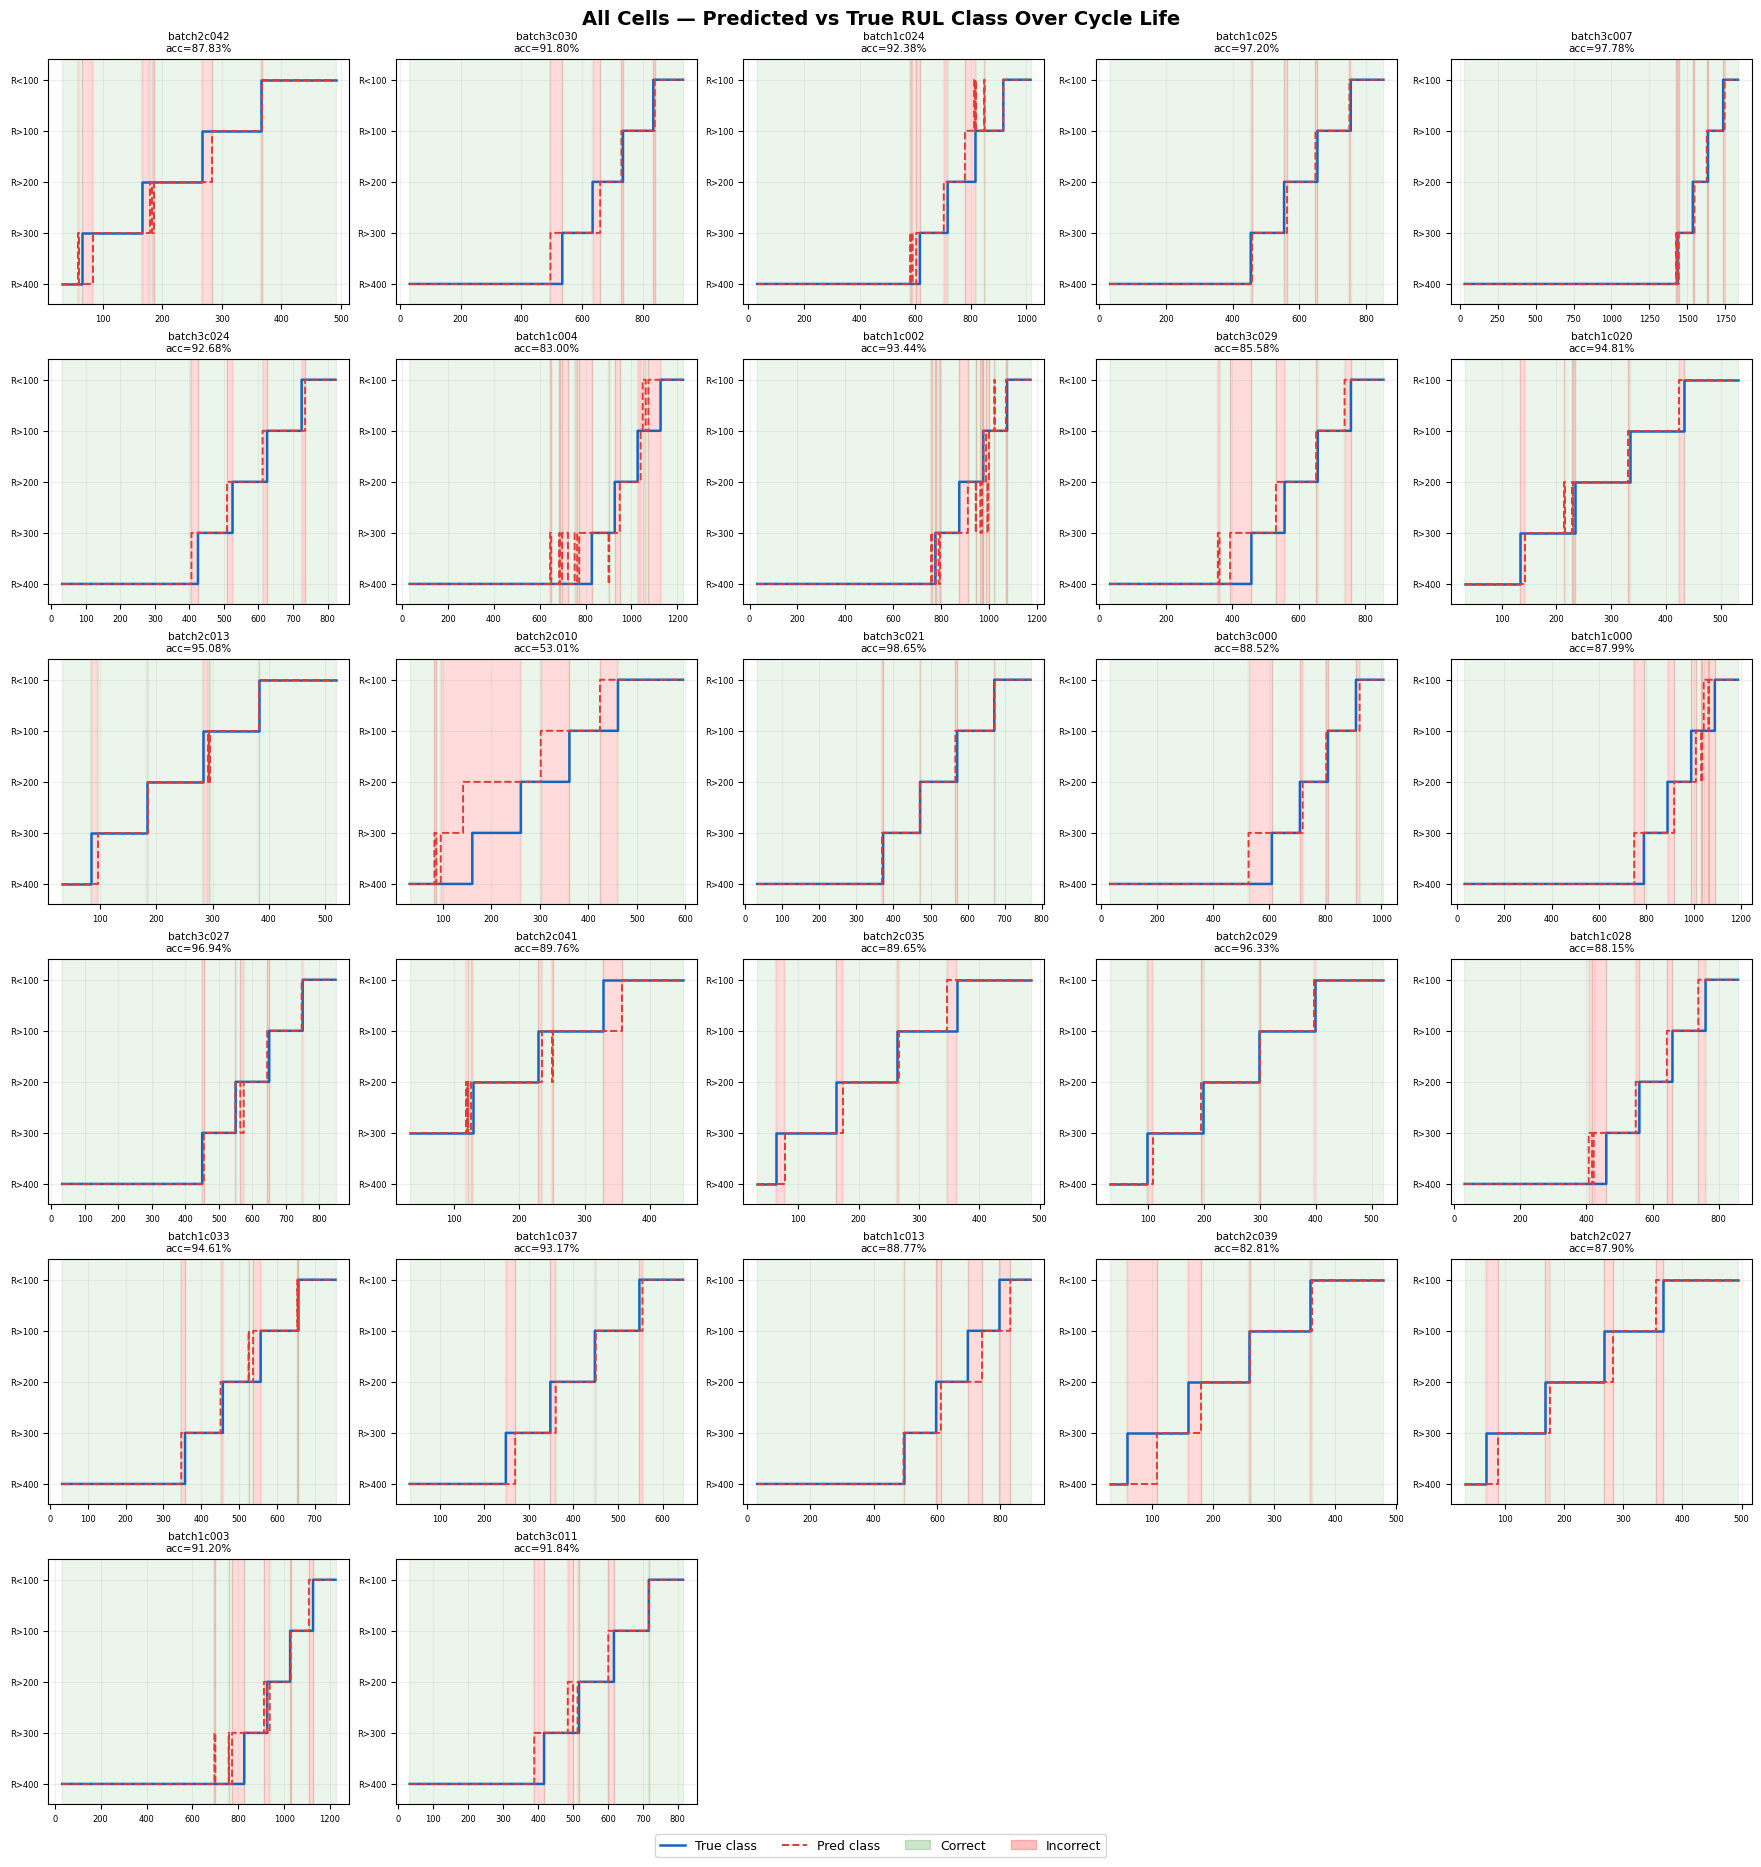


All-cell accuracy  mean=0.9003  std=0.0838  min=0.5301  max=0.9865


In [9]:
# ── Run inference on ALL cells ────────────────────────────────────────────────
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

print("Running inference on all cells...")
all_results = {}
test_cell = {}
for cellname in TestCellName:
    test_cell[cellname] =  all_cells[cellname]

for cid, cell in test_cell.items():
    r = predict_cell(cell, scalers=scalers)
    if r is not None and len(r["end_cycles"]) > 0:
        all_results[cid] = r
print(f"Predicted {len(all_results)} cells")

# ── Grid plot ─────────────────────────────────────────────────────────────────
n     = len(all_results)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3),
                         constrained_layout=True)
fig.suptitle("All Cells — Predicted vs True RUL Class Over Cycle Life",
             fontsize=14, fontweight="bold", y=1.01)

axes_flat = axes.flatten() if n > 1 else [axes]

for ax, (cid, r) in zip(axes_flat, all_results.items()):
    cyc      = r["end_cycles"]
    pred_cls = r["pred_classes"]
    true_cls = r["true_classes"]
    correct  = pred_cls == true_cls

    ax.step(cyc, true_cls, where="post", color="#1565C0", lw=1.8)
    ax.step(cyc, pred_cls, where="post", color="#E53935", lw=1.4, ls="--")

    ax.fill_between(cyc, -0.4, N_CLASSES - 0.6,
                    where=correct,  alpha=0.08, color="green", step="post")
    ax.fill_between(cyc, -0.4, N_CLASSES - 0.6,
                    where=~correct, alpha=0.14, color="red",   step="post")

    ax.set_yticks(range(N_CLASSES))
    ax.set_yticklabels(["R>400", "R>300", "R>200", "R>100", "R<100"], fontsize=5)
    ax.set_ylim(-0.4, N_CLASSES - 0.6)
    ax.set_title(f"{cid}\nacc={r['accuracy']:.2%}", fontsize=7.5)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.2)

for ax in axes_flat[len(all_results):]:
    ax.set_visible(False)

legend_elements = [
    Line2D([0], [0], color="#1565C0", lw=1.8,          label="True class"),
    Line2D([0], [0], color="#E53935", lw=1.4, ls="--", label="Pred class"),
    mpatches.Patch(color="green", alpha=0.2,            label="Correct"),
    mpatches.Patch(color="red",   alpha=0.25,           label="Incorrect"),
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.savefig("all_cells_clf.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
accs = [r["accuracy"] for r in all_results.values()]
print(f"\nAll-cell accuracy  mean={np.mean(accs):.4f}  "
      f"std={np.std(accs):.4f}  "
      f"min={np.min(accs):.4f}  "
      f"max={np.max(accs):.4f}")

## 5 — All cells overlay — coloured by cycle life

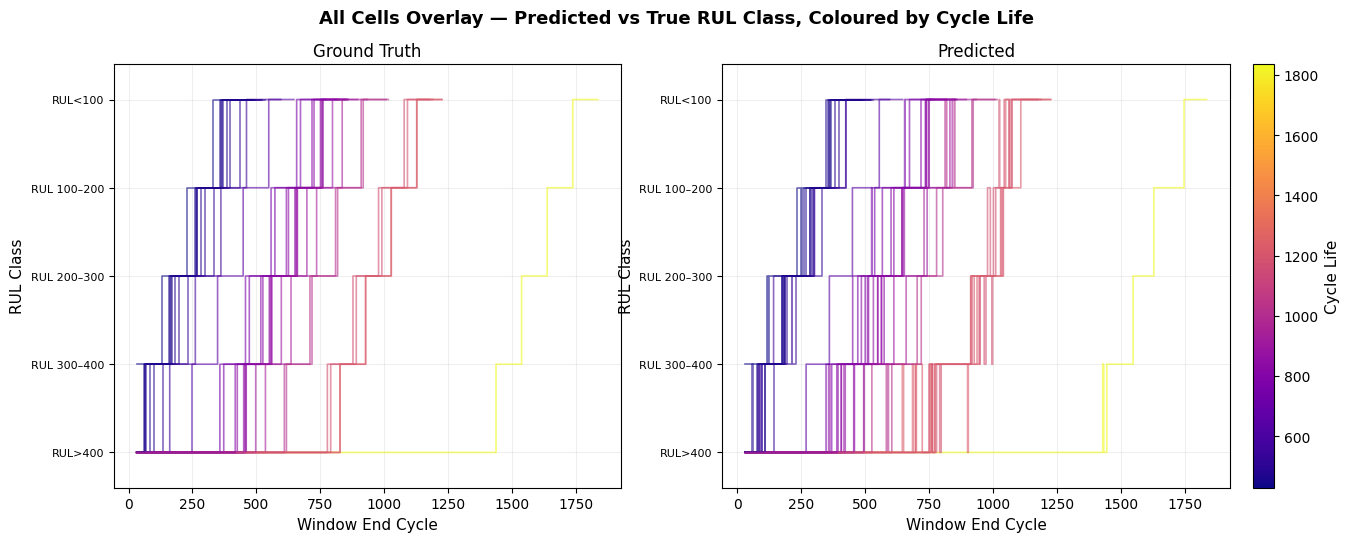

In [11]:
from matplotlib import colormaps

cycle_lives = [r["cycle_life"] for r in all_results.values()]
vmin, vmax  = min(cycle_lives), max(cycle_lives)
cmap        = colormaps.get_cmap("plasma")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle("All Cells Overlay — Predicted vs True RUL Class, Coloured by Cycle Life",
             fontsize=13, fontweight="bold")

for ax, key in zip(axes, ["true_classes", "pred_classes"]):
    label = "Ground Truth" if key == "true_classes" else "Predicted"
    for r in all_results.values():
        cyc   = r["end_cycles"]
        color = cmap((r["cycle_life"] - vmin) / (vmax - vmin + 1e-9))
        ax.step(cyc, r[key], where="post", color=color, alpha=0.6, lw=1.2)

    ax.set_yticks(range(N_CLASSES))
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_ylim(-0.4, N_CLASSES - 0.6)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Window End Cycle", fontsize=11)
    ax.set_ylabel("RUL Class", fontsize=11)
    ax.grid(True, alpha=0.2)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label("Cycle Life", fontsize=11)

plt.savefig("overlay_all_cells_clf.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 — Estimation Near End of Life (NEOL)

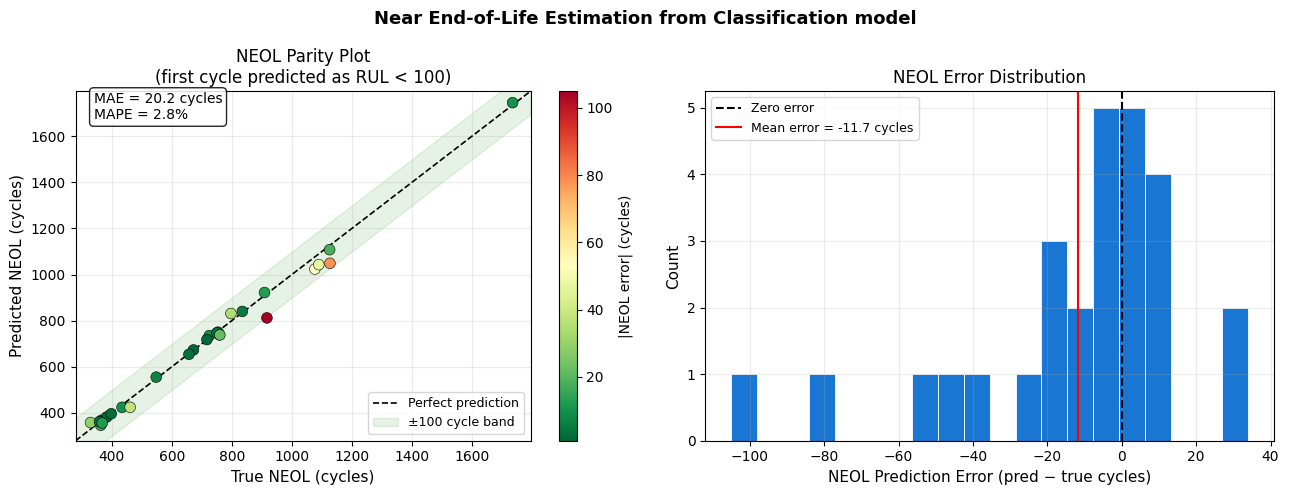

Cells evaluated : 27
NEOL MAE         : 20.2 cycles
NEOL MAPE        : 2.8%
Mean error      : -11.7 cycles  (+ = over-predict)
Std error       : 29.8 cycles


In [12]:
# ── NEOL estimation from sliding-window predictions ────────────────────────────
# NEOL = first window-end cycle where predicted/true class == 4 (RUL < 100)

eol_true_list, eol_pred_list, cid_list = [], [], []

for cid, r in all_results.items():
    cycles   = r["end_cycles"]
    true_cls = r["true_classes"]
    pred_cls = r["pred_classes"]

    # true NEOL: first cycle where true class == 4, fallback to cycle_life
    true_hits = cycles[true_cls == 4]
    eol_true  = int(true_hits[0]) if len(true_hits) > 0 else r["cycle_life"]

    # pred NEOL: first cycle where predicted class == 4, fallback to last cycle
    pred_hits = cycles[pred_cls == 4]
    eol_pred  = int(pred_hits[0]) if len(pred_hits) > 0 else int(cycles[-1])

    eol_true_list.append(eol_true)
    eol_pred_list.append(eol_pred)
    cid_list.append(cid)

eol_true = np.array(eol_true_list)
eol_pred = np.array(eol_pred_list)
eol_err  = eol_pred - eol_true

mae_eol  = float(np.mean(np.abs(eol_err)))
mape_eol = float(np.mean(np.abs(eol_err) / (eol_true + 1e-6)) * 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Near End-of-Life Estimation from Classification model", fontsize=13, fontweight="bold")

# ── Parity plot ───────────────────────────────────────────────────────────────
ax  = axes[0]
lim = [min(eol_true.min(), eol_pred.min()) - 50,
       max(eol_true.max(), eol_pred.max()) + 50]

sc = ax.scatter(eol_true, eol_pred, c=np.abs(eol_err),
                cmap="RdYlGn_r", s=60, edgecolors="k", linewidths=0.4, zorder=3)
plt.colorbar(sc, ax=ax, label="|NEOL error| (cycles)")
ax.plot(lim, lim, "k--", lw=1.2, label="Perfect prediction")
ax.fill_between(lim, [l - 100 for l in lim], [l + 100 for l in lim],
                alpha=0.1, color="green", label="±100 cycle band")
ax.set_xlabel("True NEOL (cycles)",      fontsize=11)
ax.set_ylabel("Predicted NEOL (cycles)", fontsize=11)
ax.set_title("NEOL Parity Plot\n(first cycle predicted as RUL < 100)")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)
ax.text(0.04, 0.92, f"MAE = {mae_eol:.1f} cycles\nMAPE = {mape_eol:.1f}%",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

# ── Error histogram ───────────────────────────────────────────────────────────
ax = axes[1]
ax.hist(eol_err, bins=20, color="#1976D2", edgecolor="white", linewidth=0.6)
ax.axvline(0,              color="black", lw=1.5, ls="--", label="Zero error")
ax.axvline(eol_err.mean(), color="red",   lw=1.5, ls="-",
           label=f"Mean error = {eol_err.mean():.1f} cycles")
ax.set_xlabel("NEOL Prediction Error (pred − true cycles)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("NEOL Error Distribution")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("eol_parity_clf.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Cells evaluated : {len(eol_true)}")
print(f"NEOL MAE         : {mae_eol:.1f} cycles")
print(f"NEOL MAPE        : {mape_eol:.1f}%")
print(f"Mean error      : {eol_err.mean():.1f} cycles  (+ = over-predict)")
print(f"Std error       : {eol_err.std():.1f} cycles")

## 7 — Per-Cell Summary Table

In [13]:
# ── Per-cell results table ─────────────────────────────────────────────────────
print(f'{"Cell":>12} | {"CycLife":>7} | {"NEOL_True":>8} | {"NEOL_Pred":>8} | '
      f'{"NEOL_Err":>8} | {"Acc":>7}')
print('-' * 62)

for cid in sorted(all_results.keys()):
    r        = all_results[cid]
    cycles   = r["end_cycles"]
    true_cls = r["true_classes"]
    pred_cls = r["pred_classes"]

    true_hits = cycles[true_cls == 4]
    eol_t     = int(true_hits[0]) if len(true_hits) > 0 else r["cycle_life"]

    pred_hits = cycles[pred_cls == 4]
    eol_p     = int(pred_hits[0]) if len(pred_hits) > 0 else int(cycles[-1])

    err = eol_p - eol_t
    print(f'{cid:>12} | {r["cycle_life"]:7d} | {eol_t:8d} | '
          f'{eol_p:8d} | {err:+8d} | {r["accuracy"]:7.2%}')

print('-' * 62)
print(f'{"MEAN":>12} | {"":>7} | {"":>8} | {"":>8} | '
      f'{eol_err.mean():+8.1f} | {np.mean([r["accuracy"] for r in all_results.values()]):7.2%}')
print(f'{"MAE":>12} | {"":>7} | {"":>8} | {"":>8} | '
      f'{mae_eol:8.1f} | ')
print(f'{"MAPE":>12} | {"":>7} | {"":>8} | {"":>8} | '
      f'{mape_eol:7.1f}% | ')

        Cell | CycLife | NEOL_True | NEOL_Pred | NEOL_Err |     Acc
--------------------------------------------------------------
  batch1c000 |    1190 |     1090 |     1043 |      -47 |  87.99%
  batch1c002 |    1177 |     1077 |     1024 |      -53 |  93.44%
  batch1c003 |    1226 |     1126 |     1108 |      -18 |  91.20%
  batch1c004 |    1227 |     1127 |     1049 |      -78 |  83.00%
  batch1c013 |     897 |      797 |      831 |      +34 |  88.77%
  batch1c020 |     534 |      434 |      424 |      -10 |  94.81%
  batch1c024 |    1017 |      917 |      812 |     -105 |  92.38%
  batch1c025 |     854 |      754 |      750 |       -4 |  97.20%
  batch1c028 |     860 |      760 |      738 |      -22 |  88.15%
  batch1c033 |     757 |      657 |      654 |       -3 |  94.61%
  batch1c037 |     648 |      548 |      555 |       +7 |  93.17%
  batch2c010 |     561 |      461 |      424 |      -37 |  53.01%
  batch2c013 |     483 |      383 |      382 |       -1 |  95.08%
  batch2c02

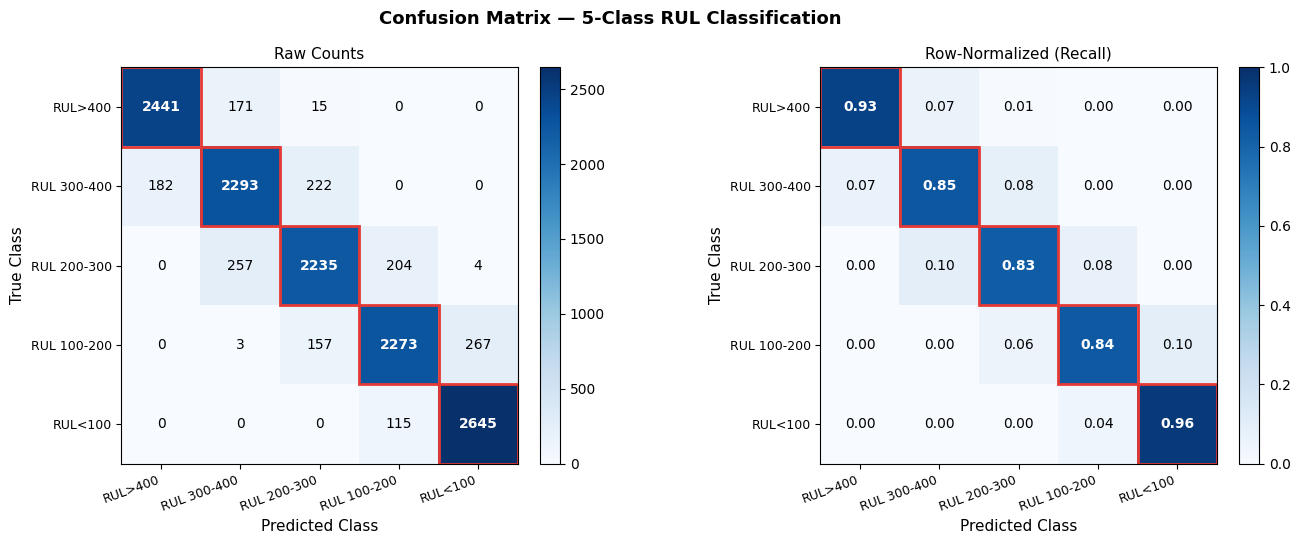

Saved: images/fig_confusion_matrix.png

       Class |  Precision |   Recall |       F1 |  Support
----------------------------------------------------------
     RUL>400 |      0.931 |    0.929 |    0.930 |     2627
 RUL 300-400 |      0.842 |    0.850 |    0.846 |     2697
 RUL 200-300 |      0.850 |    0.828 |    0.839 |     2700
 RUL 100-200 |      0.877 |    0.842 |    0.859 |     2700
     RUL<100 |      0.907 |    0.958 |    0.932 |     2760

Overall accuracy: 0.8816  (11,887 / 13,484)


In [14]:
# ── Confusion Matrix Visualization ───────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# cm = np.array([
#  [2166,  459,    2,    0,    0],
#  [ 117, 2230,  350,    0,    0],
#  [   0,  344, 2149,  207,    0],
#  [   0,    0,  357, 2019,  324],
#  [   0,    0,    0,  274, 2486],
# ])

cm = np.array([
    [2441, 171,  15,   0,   0],
    [ 182, 2293, 222,   0,   0],
    [   0, 257, 2235, 204,   4],
    [   0,   3, 157, 2273, 267],
    [   0,   0,   0, 115, 2645],
])

CLASS_NAMES = ['RUL>400', 'RUL 300-400', 'RUL 200-300', 'RUL 100-200', 'RUL<100']

# normalize by row (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Confusion Matrix — 5-Class RUL Classification', fontsize=13, fontweight='bold')

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Raw Counts', 'Row-Normalized (Recall)'],
    ['.0f', '.2f']
):
    im = ax.imshow(data, cmap='Blues', vmin=0,
                   vmax=data.max() if fmt == '.0f' else 1.0)

    # annotate cells
    thresh = data.max() / 2.0
    for i in range(5):
        for j in range(5):
            val   = data[i, j]
            color = 'white' if val > thresh else 'black'
            ax.text(j, i, format(val, fmt), ha='center', va='center',
                    fontsize=10, color=color, fontweight='bold' if i == j else 'normal')

    # diagonal border highlight
    for k in range(5):
        ax.add_patch(plt.Rectangle((k - 0.5, k - 0.5), 1, 1,
                     fill=False, edgecolor='#E53935', linewidth=2.0))

    ax.set_xticks(range(5)); ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right', fontsize=9)
    ax.set_yticks(range(5)); ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax.set_xlabel('Predicted Class', fontsize=11)
    ax.set_ylabel('True Class', fontsize=11)
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('images/fig_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/fig_confusion_matrix.png')

# ── Per-class stats ───────────────────────────────────────────────────────────
print(f'\n{"Class":>12} | {"Precision":>10} | {"Recall":>8} | {"F1":>8} | {"Support":>8}')
print('-' * 58)
for i, name in enumerate(CLASS_NAMES):
    tp  = cm[i, i]
    fp  = cm[:, i].sum() - tp
    fn  = cm[i, :].sum() - tp
    p   = tp / (tp + fp) if (tp + fp) > 0 else 0
    r   = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1  = 2 * p * r / (p + r) if (p + r) > 0 else 0
    sup = cm[i, :].sum()
    print(f'{name:>12} | {p:>10.3f} | {r:>8.3f} | {f1:>8.3f} | {sup:>8d}')
acc = np.trace(cm) / cm.sum()
print(f'\nOverall accuracy: {acc:.4f}  ({np.trace(cm):,} / {cm.sum():,})')